# ⚾ 비패스트볼 피장타 후 재대결: 피장타 구종의 평소 구사율에 따라 회피군·재사용군의 모델 선택점수 차이가 달라지는가

* **작성자:** DY
* **최초 작성:** 2026-10-05 · **보강:** 2026-10-06
* **분석 범위:** 장타(2루타 이상)를 맞은 구종이 **패스트볼 계열이 아닌** 경우의, 같은 타자와의 재대결 타석

## 1. 연구 흐름: 노트북 09 → 노트북 11

**노트북 09**는 재대결 전체를 대상으로 "장타를 맞은 구종을 다시 던지지 않은 타석(회피군)과 다시 던진
타석(재사용군)의 모델 선택점수가 평균적으로 다른가"를 봤습니다. 차이는 통계적으로 0과 구별됐지만
크기가 매우 작았습니다(이 노트북 3절에서 같은 모형을 다시 적합해 수치를 재현합니다).

평균이 작다고 해서 모든 상황에서 차이가 작다는 뜻은 아닙니다. 맞은 구종이 가끔 섞는 구종일 때와
평소 많이 의존하는 구종일 때는 "그 구종을 피한다"는 선택의 의미가 다를 수 있습니다. 그래서 이 노트북의
질문은 다음과 같습니다.

> **피장타 구종의 평소 구사율에 따라, 회피군과 재사용군의 모델 선택점수 차이가 달라지는가?**

읽기 전에 알아둘 점:

* **09와 11은 표본 범위가 다릅니다.** 09는 패스트볼을 포함한 재대결 전체이고, 11은 비패스트볼 피장타만
  봅니다. 따라서 11의 결과가 09의 작은 평균을 정확히 분해한 것이라고 말할 수 없습니다.
* **패스트볼을 제외하는 이유.** 패스트볼은 카운트를 잡기 위해 계속 던져야 하는 구종이라, "맞은 구종을
  피한다"는 선택이 변화구를 피하는 것과 의미가 다릅니다. 패스트볼을 포함하면 어떻게 되는지는 8절
  민감도 분석에서 따로 보여줍니다.
* **기존 결과 재현과 새 검증을 구분합니다.** 3~5절은 기존 모형(전체 시즌으로 GBM 적합, 시즌 전체
  구사율)을 그대로 재현하고 그 결과를 자세히 풀어 보는 부분이고, 6~8절이 이번에 추가한 검증(시간
  순서를 지킨 평가, 투수 단위 전체 과정 부트스트랩, 민감도 분석)입니다. 최종 결론(9절)은 새 검증
  결과에 맞춰 코드가 출력합니다.

## 2. 모델 선택점수의 정의와 읽는 법

GBM은 "상황 + 구종 → 그 투구가 타석을 끝냈을 때의 기대 `woba_value`"를 예측합니다. 같은 투구에서
구종만 바꿔 두 번 예측한 차이가 선택점수입니다.

$$\text{투구별 선택점수} = \text{예측}(\text{피장타 구종 재사용}) - \text{예측}(\text{실제 구종})$$

$$\text{타석 내 평균 모델 선택점수} = \text{해당 타석 투구별 선택점수의 평균}$$

* 구종을 바꿀 때는 **그 구종의 구사율 입력도 함께** 바꿉니다.
* 점수가 양수면 "모델 기준으로 실제 구종이 피장타 구종보다 기대 피해가 낮았다"는 뜻입니다.
* **이 점수는 타석당 실제 wOBA 개선량이 아닙니다.** GBM은 타석을 끝낸 투구만으로 학습됐는데 타석의
  모든 투구에 적용됩니다. 따라서 점수는 "이 투구가 타석을 끝냈다면"이라는 가정 아래의 모델 예측
  차이이고, 타석 전체 전략의 인과효과도 아닙니다.
* **실제로 관측된 카운트 경로를 고정한 평가입니다.** 다른 구종을 던졌다면 볼카운트 진행 자체가
  달라졌겠지만, 여기서는 실제 볼카운트를 그대로 두고 구종만 바꿉니다.
* **`avoided`**는 재대결 타석 전체에서 피장타 구종을 한 번도 던지지 않은 경우(=1)입니다. 재사용군
  (=0)도 피장타 구종이 아닌 다른 구종을 던진 투구를 포함하므로, 재사용군의 타석 평균 점수가 반드시
  0인 것은 아닙니다.
* **회귀계수는 "회피군 − 재사용군"의 조정된 점수 차이**입니다. 이 차이가 음수라는 것과 회피군 자체의
  점수가 음수라는 것은 다른 이야기입니다. 두 집단 각각의 점수 수준은 5절에서 따로 봅니다.

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import time
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import patsy
import rpy2.robjects as ro
from IPython.display import Markdown, display
from scipy import stats
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score

from src.analysis.avoidance_stats import compute_season_usage_rate
from src.analysis.glmer_runner import (
    check_convergence,
    extract_design_means,
    extract_fixed_effects_vcov,
    extract_lmer_fixed_effects,
    fit_lmer,
)
from src.analysis.run_same_batter_rematch_analysis import build_xbh_rematch
from src.analysis.selection_score import (
    build_pregame_counts,
    common_support,
    conditional_difference,
    expand_by_pitcher,
    lookup_pregame_usage,
    selection_score_parts,
    smoothed_usage,
    standardized_group_curves,
    tune_smoothing_k,
)
from src.preprocessing.pitch_family import CUTTER_CODE, FASTBALL_CODES, map_pitch_family
from src.preprocessing.research_sample import KEY_COLUMNS, list_research_csvs
from src.visualization.pitch_type_reuse_plots import _use_korean_font

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 60)
_use_korean_font()

RANDOM_STATE = 20261003
OOT_FOLD_SEASONS = (2022, 2023, 2024, 2025, 2026)  # 각 시즌을 그 이전 시즌들로 학습한 GBM으로 평가
PRIMARY_EVAL_SEASON = 2026                          # 명세의 주 분할: 2021~2025 학습, 2026 평가
N_BOOT = int(os.environ.get('NB11_N_BOOT', 200))    # 전체 과정 부트스트랩 반복 수
MIN_PRIOR_PITCHES = 100                             # 전년도 기록이 없을 때 시즌 누적 구사율을 쓰기 위한 최소 투구 수
SMOOTHING_K_CANDIDATES = (5, 10, 25, 50, 100, 200, 400, 800)
USAGE_BINS = [0.0, 0.10, 0.20, 0.30, 0.40, 1.0]     # 결과를 보기 전에 정한 구사율 구간
REPORT_USAGE_POINTS = (0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50)
COLOR_AVOIDED, COLOR_REUSED, COLOR_INK = '#0072B2', '#D55E00', '#333333'
GROUP_LABEL = {1: '회피군', 0: '재사용군'}
SCORE_LABEL = '타석 내 평균 모델 선택점수'
FIG_DIR = os.path.join('..', 'docs', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

Error importing in API mode: ImportError("dlopen(/Users/dongyunkwak/GitHub/9th-first-project-baseball-2/.venv/lib/python3.14/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.6/Resources/lib/libRblas.dylib\n  Referenced from: <9F0E20C3-D782-31B5-943E-66F62BCE77E8> /Users/dongyunkwak/GitHub/9th-first-project-baseball-2/.venv/lib/python3.14/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.6/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.6/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.6/Resources/lib/libRblas.dylib' (no such file)")


Trying to import in ABI mode.


## 3. 데이터 준비와 기존 결과 재현

### 3-1. 데이터와 GBM (노트북 09와 동일한 절차)

In [2]:
LOAD_COLUMNS = [
    'game_pk', 'game_date', 'at_bat_number', 'pitch_number', 'pitcher', 'player_name', 'batter',
    'stand', 'p_throws', 'pitch_type', 'events', 'balls', 'strikes', 'outs_when_up',
    'inning', 'inning_topbot', 'on_1b', 'on_2b', 'on_3b', 'home_score', 'away_score',
    'woba_value', 'woba_denom',
]
frames = [pd.read_csv(p, usecols=LOAD_COLUMNS, encoding='utf-8-sig', low_memory=False) for p in list_research_csvs()]
pitches = pd.concat(frames, ignore_index=True)
pitches['game_date'] = pd.to_datetime(pitches['game_date'])
pitches['season'] = pitches['game_date'].dt.year
assert not pitches.duplicated(KEY_COLUMNS).any()

on1, on2, on3 = pitches['on_1b'].notna(), pitches['on_2b'].notna(), pitches['on_3b'].notna()
pitches['runners_n'] = on1.astype(int) + on2.astype(int) + on3.astype(int)
pitches['risp'] = (on2 | on3).astype(int)
pitches['score_diff'] = np.where(pitches['inning_topbot'] == 'Top', pitches['home_score'] - pitches['away_score'],
                                 pitches['away_score'] - pitches['home_score'])
pitches['platoon_match'] = np.where(pitches['stand'].isna() | pitches['p_throws'].isna(), np.nan,
                                    (pitches['stand'] == pitches['p_throws']).astype(float))
print(f'투구 {len(pitches):,}건, 투수 {pitches["pitcher"].nunique():,}명, 시즌 {sorted(pitches["season"].unique())}')

투구 3,592,302건, 투수 1,067명, 시즌 [np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]


In [3]:
CONTEXT_FEATURES = ['stand', 'p_throws', 'balls', 'strikes', 'outs_when_up', 'runners_n', 'risp', 'score_diff']
FEATURES_SEASON = ['pitch_type', *CONTEXT_FEATURES, 'season_usage_rate']    # 기존 모형: 시즌 전체 구사율
FEATURES_PREGAME = ['pitch_type', *CONTEXT_FEATURES, 'pregame_usage']       # 보강: 경기 시작 전 구사율
FEATURES_NO_USAGE = ['pitch_type', *CONTEXT_FEATURES]                       # 민감도: 구사율 입력 제거
CATEGORICAL = ['pitch_type', 'stand', 'p_throws']
COV_DECISIVE = ['outs_when_up', 'score_diff', 'platoon_match', 'risp', 'runners_n']
COV_START = [f'{c}_start' for c in COV_DECISIVE]
PA_KEYS = ['game_pk', 'at_bat_number']

season_usage = compute_season_usage_rate(pitches)
decisive_table = pitches[pitches['woba_value'].notna() & pitches['pitch_type'].notna()].merge(
    season_usage[['pitcher', 'season', 'pitch_type', 'season_usage_rate']], on=['pitcher', 'season', 'pitch_type'], how='left',
)
for col in CATEGORICAL:
    decisive_table[col] = decisive_table[col].astype('category')
PITCH_DTYPE = decisive_table['pitch_type'].dtype


def fit_gbm(table: pd.DataFrame, features, seed: int = RANDOM_STATE) -> HistGradientBoostingRegressor:
    model = HistGradientBoostingRegressor(categorical_features='from_dtype', random_state=seed, max_iter=200, early_stopping=True)
    return model.fit(table[features], table['woba_value'])


gbm_full_season = fit_gbm(decisive_table, FEATURES_SEASON)
print(f'타석 종료 투구 {len(decisive_table):,}건으로 GBM 적합 (전체 시즌, 기존 모형)')

타석 종료 투구 917,717건으로 GBM 적합 (전체 시즌, 기존 모형)


In [4]:
xbh = build_xbh_rematch(pitches, season_usage)
xbh = xbh[xbh['has_next_ab']].copy()
xbh['game_date'] = pd.to_datetime(xbh['game_date'])
rematch_all = xbh[['game_pk', 'pitcher', 'season', 'game_date', 'next_at_bat_number', 'hit_pitch_type', 'reused_same_type']].rename(
    columns={'next_at_bat_number': 'at_bat_number'})
rematch_all['at_bat_number'] = rematch_all['at_bat_number'].astype(int)

# 노트북 09와 같은 표본 규칙: 재대결 타석의 종료 투구와 필수값이 있어야 함
ending = decisive_table[['game_pk', 'pitcher', 'at_bat_number', 'pitch_type', *CONTEXT_FEATURES, 'season_usage_rate',
                         'platoon_match', 'events', 'woba_value']]
events = rematch_all.merge(ending, on=['game_pk', 'pitcher', 'at_bat_number'], how='left', validate='many_to_one')
events['ending_pitch_family'] = events['pitch_type'].map(map_pitch_family)
events = events.dropna(subset=['woba_value', 'events', 'platoon_match', 'pitch_type', *CONTEXT_FEATURES,
                               'season_usage_rate', 'ending_pitch_family', 'reused_same_type']).copy()
events['avoided'] = (1 - events['reused_same_type']).astype(int)
events['pitcher_id'] = events['pitcher'].astype(str)
events['hit_pitch_family'] = events['hit_pitch_type'].map(map_pitch_family)

# 재대결 타석 '시작 시점'의 상황 (6절 시간 순서 검증의 공변량)
first_pitch = pitches.sort_values('pitch_number').drop_duplicates(PA_KEYS)[[*PA_KEYS, *COV_DECISIVE]]
events = events.merge(first_pitch.rename(columns=dict(zip(COV_DECISIVE, COV_START))), on=PA_KEYS, how='left')

# 기존 모형의 피장타 구종 구사율: 시즌 전체 집계 (그 시즌에 기록이 없으면 0으로 채움 -- 기존 규칙 그대로)
hit_usage_season = season_usage.rename(columns={'pitch_type': 'hit_pitch_type', 'season_usage_rate': 'hit_usage_season'})
events = events.merge(hit_usage_season[['pitcher', 'season', 'hit_pitch_type', 'hit_usage_season']],
                      on=['pitcher', 'season', 'hit_pitch_type'], how='left')
events['hit_usage_season'] = events['hit_usage_season'].fillna(0.0)
assert len(events) == 27_245, len(events)

# 재대결 타석의 모든 투구
pa_pitches = events[[*PA_KEYS, 'pitcher', 'season', 'game_date', 'hit_pitch_type', 'hit_usage_season']].merge(
    pitches[[*PA_KEYS, 'pitch_number', 'pitch_type', *CONTEXT_FEATURES]], on=PA_KEYS, how='left',
).dropna(subset=['pitch_type'])
pa_pitches = pa_pitches.merge(season_usage[['pitcher', 'season', 'pitch_type', 'season_usage_rate']],
                              on=['pitcher', 'season', 'pitch_type'], how='left').dropna(subset=['season_usage_rate'])
pa_pitches['pitch_type'] = pa_pitches['pitch_type'].astype(PITCH_DTYPE)
for col in ('stand', 'p_throws'):
    pa_pitches[col] = pa_pitches[col].astype(decisive_table[col].dtype)
pa_pitches = pa_pitches.reset_index(drop=True)
print(f'재대결 {len(events):,}건의 투구 {len(pa_pitches):,}건')


def score_pa(pa: pd.DataFrame, model, features, cf_usage_col, usage_feature) -> pd.DataFrame:
    """타석별 평균: 선택점수, 그리고 그 두 구성항(재사용 가정 예측, 실제 구종 예측)."""
    cf, actual = selection_score_parts(pa, model, features, 'hit_pitch_type', cf_usage_col, usage_feature)
    out = pa[PA_KEYS].assign(selection_score=cf - actual, pred_reuse=cf, pred_actual=actual)
    return out.groupby(PA_KEYS, sort=False)[['selection_score', 'pred_reuse', 'pred_actual']].mean().reset_index()


events = events.merge(score_pa(pa_pitches, gbm_full_season, FEATURES_SEASON, 'hit_usage_season', 'season_usage_rate'),
                      on=PA_KEYS, how='left', validate='one_to_one')
assert events['selection_score'].notna().all()

2026-10-06 13:41:47,490 [INFO] 장타 70319건 중 같은 타자·같은 투수 재대결 27391건 (39.0%)
        xbh_total  same_batter_rematch  rematch_share
season                                               
2021        12709                 4688         0.3689
2022        12186                 4623         0.3794
2023        13137                 5280         0.4019
2024        12427                 4977         0.4005
2025        12394                 4916         0.3966
2026         7466                 2907         0.3894


재대결 27,245건의 투구 106,742건


### 3-2. 분석 표본

패스트볼 계열로 분류하는 구종 코드와, 전체 재대결에서 최종 분석 표본까지의 건수입니다.

In [5]:
fastball_codes = sorted(FASTBALL_CODES | {CUTTER_CODE})
print('패스트볼 계열 구종 코드:', ', '.join(fastball_codes), '(포심·싱커·투심·기타 패스트볼·커터)')


def sample_row(label: str, df: pd.DataFrame) -> dict:
    known = df.dropna(subset=['reused_same_type'])
    return {'단계': label, '재대결 건수': len(df), '투수 수': df['pitcher'].nunique(),
            '회피군': int((known['reused_same_type'] == 0).sum()), '재사용군': int((known['reused_same_type'] == 1).sum())}


events_nonfb = events[events['hit_pitch_family'] != 'fastball'].copy()
sample_flow = pd.DataFrame([
    sample_row('① 장타 후 같은 타자 재대결 전체', rematch_all),
    sample_row('② 종료 투구·필수값이 있는 재대결 (노트북 09 표본)', events),
    sample_row('③ 그중 패스트볼 계열 피장타', events[events['hit_pitch_family'] == 'fastball']),
    sample_row('④ 비패스트볼 피장타 (이 노트북의 분석 표본)', events_nonfb),
])
display(sample_flow)
print('피장타 구종 분포(분석 표본):', events_nonfb['hit_pitch_type'].value_counts().to_dict())

패스트볼 계열 구종 코드: FA, FC, FF, FT, SI (포심·싱커·투심·기타 패스트볼·커터)


,단계,재대결 건수,투수 수,회피군,재사용군
0,① 장타 후 같은 타자 재대결 전체,27391,695,14912,12459
1,② 종료 투구·필수값이 있는 재대결 (노트북 09 표본),27245,695,14805,12440
2,③ 그중 패스트볼 계열 피장타,16498,649,7475,9023
3,④ 비패스트볼 피장타 (이 노트북의 분석 표본),10747,616,7330,3417


피장타 구종 분포(분석 표본): {'SL': 3404, 'CH': 2967, 'CU': 1773, 'ST': 1284, 'KC': 591, 'FS': 551, 'SV': 144, 'KN': 18, 'FO': 8, 'CS': 7}


### 3-3. 기존 결과 재현

혼합모형은 모두 `lmer`이고 투수 랜덤절편 `(1 | pitcher)`를 둡니다. 여기서는 기존 노트북과 똑같이
타석 종료 투구 시점의 상황 공변량과 시즌 전체 구사율을 씁니다(6절에서 이 두 가지를 바꿉니다).

In [6]:
def fit_mixed(data: pd.DataFrame, outcome: str, usage_c: str | None, covars, season_fe: bool = True) -> dict:
    rhs = f'avoided * {usage_c}' if usage_c else 'avoided'
    formula = f"{outcome} ~ {rhs} + {' + '.join(covars)}{' + factor(season)' if season_fe else ''} + (1 | pitcher_id)"
    cols = [outcome, 'avoided', *([usage_c] if usage_c else []), *covars, 'season', 'pitcher_id']
    fit_lmer(data[cols], formula)
    return {'formula': formula, 'coef': extract_lmer_fixed_effects().set_index('term'), 'vcov': extract_fixed_effects_vcov(),
            'design_means': extract_design_means(), 'convergence': check_convergence(),
            'n': len(data), 'n_pitchers': data['pitcher_id'].nunique()}


def delta_at(fit: dict, usage_raw, center: float, usage_c: str):
    c, v, it = fit['coef'], fit['vcov'], f'avoided:{usage_c}'
    return conditional_difference(np.asarray(usage_raw, dtype=float) - center, c.loc['avoided', 'estimate'],
                                  c.loc[it, 'estimate'], v.loc['avoided', 'avoided'], v.loc[it, it], v.loc['avoided', it])


def summarize_interaction(label: str, fit: dict, center: float, usage_c: str) -> dict:
    it = fit['coef'].loc[f'avoided:{usage_c}']
    row = {'사양': label, '재대결 건수': fit['n'], '투수 수': fit['n_pitchers'],
           '상호작용 계수': it['estimate'], '95% CI 하한': it['ci_low'], '95% CI 상한': it['ci_high'],
           '구사율 10%p당 차이 변화': 0.1 * it['estimate']}
    for u in (0.10, 0.30):
        d, se = delta_at(fit, [u], center, usage_c)
        row[f'차이(구사율 {u:.2f})'] = d[0]
        row[f'차이(구사율 {u:.2f}) 95% CI'] = f'[{d[0] - 1.96 * se[0]:+.4f}, {d[0] + 1.96 * se[0]:+.4f}]'
    return row


fit_09 = fit_mixed(events, 'selection_score', None, COV_DECISIVE)
print('[노트북 09 재현] 재대결 전체, 평균 차이 모형:', fit_09['convergence'])
display(fit_09['coef'].loc[['avoided']].round(5))

USAGE_CENTER_SEASON = float(events_nonfb['hit_usage_season'].mean())
events_nonfb['hit_usage_season_c'] = events_nonfb['hit_usage_season'] - USAGE_CENTER_SEASON
fit_base = fit_mixed(events_nonfb, 'selection_score', 'hit_usage_season_c', COV_DECISIVE)
print(f'[노트북 11 기존 모형 재현] 비패스트볼 피장타, 상호작용 모형 (평균 구사율 {USAGE_CENTER_SEASON:.3f}):', fit_base['convergence'])
display(fit_base['coef'].loc[['avoided', 'hit_usage_season_c', 'avoided:hit_usage_season_c']].round(5))

2026-10-06 13:42:18,103 [WARNING] R callback write-console: Loading required package: Matrix
  


[노트북 09 재현] 재대결 전체, 평균 차이 모형: OK: no convergence warnings; isSingular=False


,estimate,std_error,t_value,ci_low,ci_high,p_value
term,,,,,,
avoided,0.00227,0.00029,7.91105,0.00171,0.00284,0.0


[노트북 11 기존 모형 재현] 비패스트볼 피장타, 상호작용 모형 (평균 구사율 0.213): OK: no convergence warnings; isSingular=False


,estimate,std_error,t_value,ci_low,ci_high,p_value
term,,,,,,
avoided,0.00286,0.00053,5.44829,0.00183,0.00389,0.0
hit_usage_season_c,-0.06699,0.00468,-14.31437,-0.07616,-0.05781,0.0
avoided:hit_usage_season_c,-0.06446,0.00531,-12.14494,-0.07486,-0.05406,0.0


## 4. 구사율별 차이와 신뢰구간 (기존 모형)

선형 상호작용 모형에서 구사율 $u$일 때의 "회피군 − 재사용군" 조정 차이는

$$\Delta(u) = \beta_{\text{avoided}} + \beta_{\text{interaction}} \times (u - \bar u)$$

이고, 표준오차는 두 계수의 분산과 **공분산**을 모두 넣어 계산합니다.

* 아래 신뢰구간은 **GBM이 만든 점수를 고정된 값으로 놓았을 때**의 조건부 불확실성입니다. GBM을 다시
  학습할 때 점수 자체가 흔들리는 부분은 여기에 들어 있지 않고, 7절 부트스트랩에서 따로 다룹니다.
* 곡선이 0을 지나는 지점은 **합리성과 비합리성을 가르는 임계값이 아닙니다.** 선형 가정 아래에서
  두 집단의 모델 점수 차이의 부호가 바뀌는 위치의 점추정일 뿐이고, 그 주변에서는 신뢰구간이 0을
  포함합니다.
* 두 집단의 관측치가 함께 있는 구간(각 집단 구사율의 2.5~97.5% 범위가 겹치는 구간)을 '공통 관측
  구간'으로 표시하고, 그 밖은 외삽이므로 주요 결론에 쓰지 않습니다.

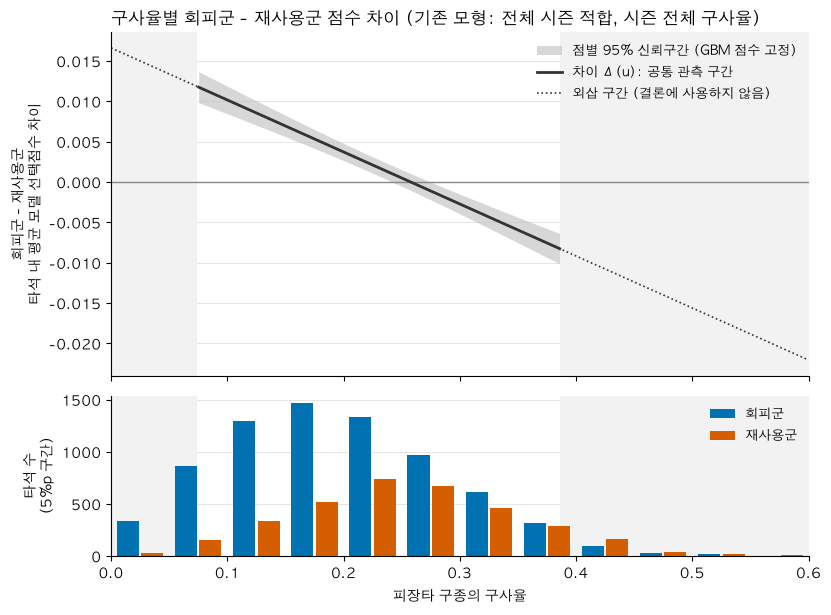

공통 관측 구간: 구사율 0.074 ~ 0.386 (회색 음영은 그 밖)

미리 정한 구사율 구간별 타석 수:


avoided,재사용군,회피군
구사율 구간,,
"[0.0, 0.1)",179,1195
"[0.1, 0.2)",857,2761
"[0.2, 0.3)",1408,2301
"[0.3, 0.4)",751,921
"[0.4, 1.0)",222,152


공통 관측 구간 안의 구사율 지점별 차이:


,구사율,회피군−재사용군 차이,표준오차,95% CI 하한,95% CI 상한
0,0.10,0.01015,0.00087,0.00844,0.01186
1,0.15,0.00693,0.00068,0.00560,0.00826
2,0.20,0.00370,0.00054,0.00264,0.00477
3,0.25,0.00048,0.00052,-0.00054,0.00151
4,0.30,-0.00274,0.00063,-0.00397,-0.00152
5,0.35,-0.00596,0.00081,-0.00754,-0.00438


구사율이 10%p 높아질 때 집단 간 점수 차이의 변화: -0.00645 [95% CI -0.00749, -0.00541] (GBM 점수 고정)


In [7]:
def usage_bin_counts(data: pd.DataFrame, usage_col: str) -> pd.DataFrame:
    binned = pd.cut(data[usage_col], USAGE_BINS, right=False, include_lowest=True)
    table = data.groupby([binned, 'avoided'], observed=False).size().unstack('avoided').rename(columns=GROUP_LABEL)
    table.index = table.index.astype(str)
    table.index.name = '구사율 구간'
    return table


def supported_points(support) -> list:
    return [u for u in REPORT_USAGE_POINTS if support[0] <= u <= support[1]]


def delta_table(fit: dict, center: float, usage_c: str, support) -> pd.DataFrame:
    points = supported_points(support)
    d, se = delta_at(fit, points, center, usage_c)
    return pd.DataFrame({'구사율': points, '회피군−재사용군 차이': d, '표준오차': se,
                         '95% CI 하한': d - 1.96 * se, '95% CI 상한': d + 1.96 * se})


def plot_delta(fit: dict, data: pd.DataFrame, usage_col: str, center: float, usage_c: str, title: str, path: str):
    support = common_support(data.loc[data['avoided'] == 1, usage_col], data.loc[data['avoided'] == 0, usage_col])
    x_max = float(np.ceil(data[usage_col].quantile(0.999) * 20) / 20)
    grid = np.linspace(0.0, x_max, 200)
    d, se = delta_at(fit, grid, center, usage_c)
    inside = (grid >= support[0]) & (grid <= support[1])

    fig, (ax, ax_n) = plt.subplots(2, 1, figsize=(9, 6.8), sharex=True, gridspec_kw={'height_ratios': [3, 1.4], 'hspace': 0.08})
    ax.axhline(0, color='#888888', lw=1)
    ax.fill_between(grid[inside], (d - 1.96 * se)[inside], (d + 1.96 * se)[inside], color='#BDBDBD', alpha=0.6, lw=0,
                    label='점별 95% 신뢰구간 (GBM 점수 고정)')
    ax.plot(grid[inside], d[inside], color=COLOR_INK, lw=2, label='차이 Δ(u): 공통 관측 구간')
    ax.plot(grid[~inside], d[~inside], color=COLOR_INK, lw=1.2, ls=':', label='외삽 구간 (결론에 사용하지 않음)')
    for lo, hi in ((0.0, support[0]), (support[1], x_max)):
        ax.axvspan(lo, hi, color='#F2F2F2', lw=0)
        ax_n.axvspan(lo, hi, color='#F2F2F2', lw=0)
    ax.set_ylabel(f'회피군 - 재사용군\n{SCORE_LABEL} 차이')
    ax.set_title(title, loc='left', fontsize=12)
    ax.legend(frameon=False, fontsize=9, loc='best')
    ax.grid(axis='y', color='#E5E5E5', lw=0.7)
    ax.set_axisbelow(True)

    edges = np.arange(0.0, x_max + 1e-9, 0.05)
    width = 0.021
    for offset, group, color in ((-width / 2, 1, COLOR_AVOIDED), (width / 2, 0, COLOR_REUSED)):
        counts, _ = np.histogram(data.loc[data['avoided'] == group, usage_col], bins=edges)
        ax_n.bar(edges[:-1] + 0.025 + offset, counts, width=width - 0.002, color=color, label=GROUP_LABEL[group])
    ax_n.set_ylabel('타석 수\n(5%p 구간)')
    ax_n.set_xlabel('피장타 구종의 구사율')
    ax_n.legend(frameon=False, fontsize=9, loc='upper right')
    ax_n.grid(axis='y', color='#E5E5E5', lw=0.7)
    ax_n.set_axisbelow(True)
    ax_n.set_xlim(0, x_max)
    for a in (ax, ax_n):
        a.spines[['top', 'right']].set_visible(False)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    return support


support_base = plot_delta(fit_base, events_nonfb, 'hit_usage_season', USAGE_CENTER_SEASON, 'hit_usage_season_c',
                          '구사율별 회피군 - 재사용군 점수 차이 (기존 모형: 전체 시즌 적합, 시즌 전체 구사율)',
                          os.path.join(FIG_DIR, '11_delta_by_usage_full_season.png'))
print(f'공통 관측 구간: 구사율 {support_base[0]:.3f} ~ {support_base[1]:.3f} (회색 음영은 그 밖)')
print('\n미리 정한 구사율 구간별 타석 수:')
display(usage_bin_counts(events_nonfb, 'hit_usage_season'))
print('공통 관측 구간 안의 구사율 지점별 차이:')
display(delta_table(fit_base, USAGE_CENTER_SEASON, 'hit_usage_season_c', support_base).round(5))
_it = fit_base['coef'].loc['avoided:hit_usage_season_c']
print(f'구사율이 10%p 높아질 때 집단 간 점수 차이의 변화: {0.1 * _it["estimate"]:+.5f} '
      f'[95% CI {0.1 * _it["ci_low"]:+.5f}, {0.1 * _it["ci_high"]:+.5f}] (GBM 점수 고정)')

## 5. 두 집단 각각의 점수 (기존 모형)

4절은 두 집단의 **차이**만 보여줍니다. 차이가 음수가 되는 것이 회피군 점수가 낮아져서인지 재사용군
점수가 높아져서인지는 각 집단의 수준을 따로 봐야 알 수 있습니다.

* **관측 평균**: 구사율 구간별로 실제 타석들의 점수를 그대로 요약한 값입니다.
* **조정된 예측값**: 혼합모형의 고정효과로 계산한 곡선입니다. 다른 공변량(상황, 시즌)은 분석 표본의
  평균 분포에 맞추고, **투수 랜덤효과는 0**으로 둡니다(평균적인 투수 기준). 신뢰구간은 4절과 같이
  GBM 점수를 고정한 조건부 구간입니다.

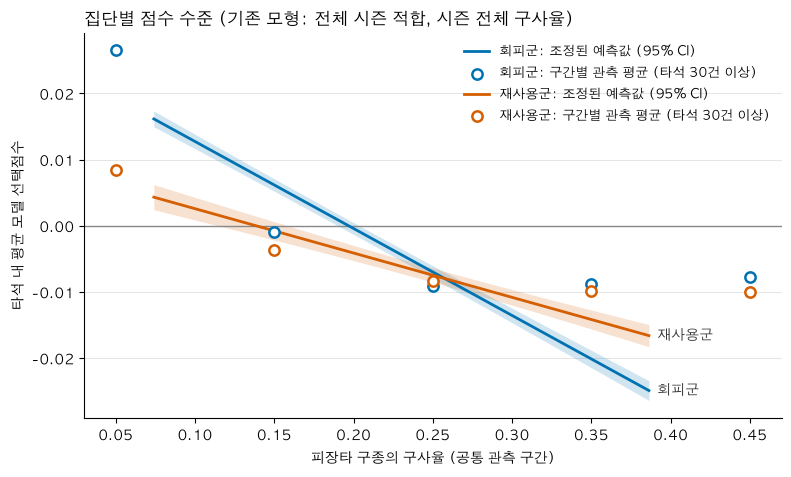

구사율 구간별 관측 요약 (조정 전 값):


,구사율 구간,집단,타석_수,투수_수,점수_평균,점수_중앙값
0,"[0.0, 0.1)",재사용군,179,111,0.00839,0.00322
1,"[0.0, 0.1)",회피군,1195,320,0.02649,0.02050
2,"[0.1, 0.2)",재사용군,857,297,-0.00363,-0.00360
3,"[0.1, 0.2)",회피군,2761,413,-0.00093,0.00081
4,"[0.2, 0.3)",재사용군,1408,314,-0.00834,-0.00661
5,"[0.2, 0.3)",회피군,2301,366,-0.00905,-0.00668
6,"[0.3, 0.4)",재사용군,751,171,-0.00982,-0.00850
7,"[0.3, 0.4)",회피군,921,178,-0.00873,-0.00834
8,"[0.4, 1.0)",재사용군,222,40,-0.00994,-0.01068
9,"[0.4, 1.0)",회피군,152,30,-0.00771,-0.00876


In [8]:
def group_bin_table(data: pd.DataFrame, usage_col: str, score_col: str = 'selection_score') -> pd.DataFrame:
    binned = pd.cut(data[usage_col], USAGE_BINS, right=False, include_lowest=True)
    table = data.groupby([binned, 'avoided'], observed=False).agg(
        타석_수=(score_col, 'size'), 투수_수=('pitcher_id', 'nunique'), 점수_평균=(score_col, 'mean'), 점수_중앙값=(score_col, 'median'),
    ).reset_index().rename(columns={usage_col: '구사율 구간'})
    table['집단'] = table['avoided'].map(GROUP_LABEL)
    table['구간 중앙'] = [iv.mid if iv.right < 1 else (iv.left + 0.05) for iv in table['구사율 구간']]
    return table[['구사율 구간', '집단', '타석_수', '투수_수', '점수_평균', '점수_중앙값', '구간 중앙', 'avoided']]


def plot_group_curves(fit: dict, data: pd.DataFrame, usage_col: str, center: float, usage_c: str, support, title: str, path: str):
    grid = np.linspace(support[0], support[1], 100)
    curves = standardized_group_curves(fit['coef']['estimate'], fit['vcov'], fit['design_means'], grid - center,
                                       'avoided', usage_c, f'avoided:{usage_c}')
    bins = group_bin_table(data, usage_col)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.axhline(0, color='#888888', lw=1)
    for group, color in ((1, COLOR_AVOIDED), (0, COLOR_REUSED)):
        c = curves[curves['avoided'] == group]
        ax.fill_between(grid, c['predicted'] - 1.96 * c['se'], c['predicted'] + 1.96 * c['se'], color=color, alpha=0.18, lw=0)
        ax.plot(grid, c['predicted'], color=color, lw=2, label=f'{GROUP_LABEL[group]}: 조정된 예측값 (95% CI)')
        b = bins[(bins['avoided'] == group) & (bins['타석_수'] >= 30)]
        ax.scatter(b['구간 중앙'], b['점수_평균'], s=55, facecolor='white', edgecolor=color, lw=1.8, zorder=3,
                   label=f'{GROUP_LABEL[group]}: 구간별 관측 평균 (타석 30건 이상)')
        ax.annotate(GROUP_LABEL[group], (grid[-1], c['predicted'].iloc[-1]), xytext=(6, 0), textcoords='offset points',
                    va='center', fontsize=10, color=COLOR_INK)
    ax.set_xlabel('피장타 구종의 구사율 (공통 관측 구간)')
    ax.set_ylabel(SCORE_LABEL)
    ax.set_title(title, loc='left', fontsize=12)
    ax.legend(frameon=False, fontsize=9)
    ax.grid(axis='y', color='#E5E5E5', lw=0.7)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    return bins.drop(columns=['구간 중앙', 'avoided'])


bins_base = plot_group_curves(fit_base, events_nonfb, 'hit_usage_season', USAGE_CENTER_SEASON, 'hit_usage_season_c', support_base,
                              '집단별 점수 수준 (기존 모형: 전체 시즌 적합, 시즌 전체 구사율)',
                              os.path.join(FIG_DIR, '11_group_scores_full_season.png'))
print('구사율 구간별 관측 요약 (조정 전 값):')
display(bins_base.round(5))

### 점수의 두 구성항

선택점수 = (피장타 구종을 재사용했다고 가정한 예측) − (실제 구종의 예측)이므로, 같은 혼합모형을 두
항 각각에 적합하면 상호작용이 어느 쪽에서 생기는지 볼 수 있습니다. 두 항의 계수 차이가 선택점수의
계수와 같습니다.

In [9]:
def decomposition_table(data: pd.DataFrame, usage_c: str, covars, season_fe: bool = True) -> pd.DataFrame:
    rows = []
    for outcome, label in (('selection_score', '선택점수 (= 재사용 가정 − 실제)'), ('pred_reuse', '재사용 가정 예측'),
                           ('pred_actual', '실제 구종 예측')):
        coef = fit_mixed(data, outcome, usage_c, covars, season_fe)['coef']
        rows.append({'결과 변수': label, 'avoided 계수': coef.loc['avoided', 'estimate'],
                     '구사율 계수': coef.loc[usage_c, 'estimate'], '상호작용 계수': coef.loc[f'avoided:{usage_c}', 'estimate'],
                     '상호작용 SE': coef.loc[f'avoided:{usage_c}', 'std_error']})
    return pd.DataFrame(rows)


decomp_base = decomposition_table(events_nonfb, 'hit_usage_season_c', COV_DECISIVE)
display(decomp_base.round(5))

,결과 변수,avoided 계수,구사율 계수,상호작용 계수,상호작용 SE
0,선택점수 (= 재사용 가정 − 실제),0.00286,-0.06699,-0.06446,0.00531
1,재사용 가정 예측,0.02446,-0.04968,-0.02500,0.01302
2,실제 구종 예측,0.02145,0.00436,0.04394,0.01196


## 6. 시간 순서를 지킨 검증 (새 검증)

기존 모형에는 시간 순서가 섞이는 지점이 세 군데 있습니다. 이 절에서 세 가지를 모두 바꿉니다.

| 기존 모형 | 이 절의 보강 |
|---|---|
| GBM을 평가 대상 시즌까지 포함해 학습 | 평가 시즌 **이전** 시즌만으로 학습한 GBM으로 점수 계산 |
| 구사율 = 그 시즌 전체 집계(재대결 이후 경기 포함) | 구사율 = **해당 경기 날짜 이전** 기록만으로 계산 |
| 상황 공변량 = 타석 종료 투구 시점 | 상황 공변량 = **재대결 타석 시작 시점** |

**경기 전 구사율의 규칙** (의존도 변수와 GBM 입력 구사율에 같은 규칙 적용):

* 전년도 기록이 있는 투수: `(올 시즌 경기 전 그 구종 투구 수 + k × 전년도 그 구종 비율) / (올 시즌 경기 전
  전체 투구 수 + k)`. 시즌 초에는 전년도 비율에 가깝고, 시즌이 진행될수록 올 시즌 기록이 지배합니다.
* 전년도 기록이 없는 투수: 올 시즌 경기 전 투구가 100개 이상 쌓인 뒤부터 그 비율을 그대로 사용.
* 둘 다 해당하지 않으면 **결측으로 두고 분석에서 제외**합니다(0으로 채우지 않음). 기록이 있는데 그
  구종을 한 번도 던지지 않은 경우의 0은 실제 정보이므로 0입니다.
* 같은 날짜의 더블헤더는 구분하지 않고 "그 날짜 이전"까지만 씁니다(1차전 기록을 2차전에 쓰지 않는
  보수적 처리).
* 평활 강도 `k`는 **2022~2025년**에서 "경기 전 구사율이 그 경기의 실제 구사율을 얼마나 잘 맞히는가"로
  고릅니다. 2026년은 이 선택에 쓰지 않습니다.

**평가 분할:** 명세의 주 분할은 2021~2025년 학습 → 2026년 평가입니다. 2026년 한 시즌은 표본이 작아
불확실성이 크므로, 같은 원칙(평가 시즌 이전만으로 학습)을 2022~2026년 각 시즌에 적용해 합친 결과도
함께 봅니다. 이 시즌들은 이미 탐색에 쓰인 자료이므로 **"한 번도 보지 않은 확증 표본"이 아니라**, 점수를
만드는 GBM의 학습에서 제외된 **시간 외 평가**입니다.

In [10]:
pregame_grid = build_pregame_counts(pitches)
SMOOTHING_K, k_table = tune_smoothing_k(pregame_grid, seasons=range(2022, PRIMARY_EVAL_SEASON), candidates=SMOOTHING_K_CANDIDATES,
                                        min_prior_pitches=MIN_PRIOR_PITCHES)
display(k_table.round(6))
print(f'선택된 평활 강도 k = {SMOOTHING_K:g} (2022~{PRIMARY_EVAL_SEASON - 1}년 기준, {PRIMARY_EVAL_SEASON}년 미사용)')
pregame_grid['usage'] = smoothed_usage(pregame_grid, SMOOTHING_K, MIN_PRIOR_PITCHES)


def pregame_usage_of(df: pd.DataFrame, type_col: str) -> np.ndarray:
    queries = df[['pitcher', 'season', 'game_date']].assign(pitch_type=df[type_col].astype(object).to_numpy())
    return lookup_pregame_usage(queries, pregame_grid, MIN_PRIOR_PITCHES).to_numpy()


decisive_table['pregame_usage'] = pregame_usage_of(decisive_table, 'pitch_type')
decisive_pre = decisive_table.dropna(subset=['pregame_usage']).reset_index(drop=True)
events['hit_usage_pregame'] = pregame_usage_of(events, 'hit_pitch_type')
pa_pitches['pregame_usage'] = pregame_usage_of(pa_pitches, 'pitch_type')
pa_pitches['hit_usage_pregame'] = pregame_usage_of(pa_pitches, 'hit_pitch_type')
print(f'GBM 학습용 종료 투구: {len(decisive_table):,}건 중 경기 전 구사율이 있는 {len(decisive_pre):,}건 사용 '
      f'({len(decisive_table) - len(decisive_pre):,}건은 이력 부족으로 제외)')
print(f'재대결: {len(events):,}건 중 경기 전 구사율이 있는 {int(events["hit_usage_pregame"].notna().sum()):,}건')
print(f'피장타 구종의 경기 전 구사율과 시즌 전체 구사율의 상관: {events["hit_usage_pregame"].corr(events["hit_usage_season"]):.3f}')

,smoothing_k,weighted_mse
0,5,0.006807
1,10,0.006779
2,25,0.006744
3,50,0.006748
4,100,0.006824
5,200,0.007038
6,400,0.007454
7,800,0.008100


선택된 평활 강도 k = 25 (2022~2025년 기준, 2026년 미사용)


GBM 학습용 종료 투구: 917,717건 중 경기 전 구사율이 있는 876,021건 사용 (41,696건은 이력 부족으로 제외)
재대결: 27,245건 중 경기 전 구사율이 있는 26,330건
피장타 구종의 경기 전 구사율과 시즌 전체 구사율의 상관: 0.967


In [11]:
X_PRE, Y_PRE, SEASON_PRE = decisive_pre[FEATURES_PREGAME], decisive_pre['woba_value'].to_numpy(), decisive_pre['season'].to_numpy()
pa_pre = pa_pitches.dropna(subset=['pregame_usage', 'hit_usage_pregame'])
pa_pre_by_season = {y: pa_pre[pa_pre['season'] == y] for y in OOT_FOLD_SEASONS}


def fit_fold_models(features, seed: int = RANDOM_STATE) -> dict:
    return {y: fit_gbm(decisive_pre[SEASON_PRE < y], features, seed) for y in OOT_FOLD_SEASONS}


def score_out_of_time(models: dict, features, cf_usage_col, usage_feature) -> pd.DataFrame:
    return pd.concat([score_pa(pa_pre_by_season[y], models[y], features, cf_usage_col, usage_feature)
                      for y in OOT_FOLD_SEASONS], ignore_index=True)


fold_models = fit_fold_models(FEATURES_PREGAME)
fold_rows = []
for y in OOT_FOLD_SEASONS:
    evaluation = decisive_pre[SEASON_PRE == y]
    fold_rows.append({'평가 시즌': y, '학습 시즌': f'2021~{y - 1}' if y > 2022 else '2021', '학습 종료 투구 수': int((SEASON_PRE < y).sum()),
                      '평가 종료 투구 수': len(evaluation),
                      '평가 시즌 R² (시간 외)': r2_score(evaluation['woba_value'], fold_models[y].predict(evaluation[FEATURES_PREGAME]))})
display(pd.DataFrame(fold_rows).round(4))

oot_scores = score_out_of_time(fold_models, FEATURES_PREGAME, 'hit_usage_pregame', 'pregame_usage')
SCORE_COLUMNS = ['selection_score', 'pred_reuse', 'pred_actual']
events_oot = events.drop(columns=SCORE_COLUMNS).merge(oot_scores, on=PA_KEYS, how='inner', validate='one_to_one')
events_oot = events_oot.dropna(subset=['hit_usage_pregame', *COV_START]).copy()
oot_nonfb = events_oot[events_oot['hit_pitch_family'] != 'fastball'].copy()
USAGE_CENTER_PRE = float(oot_nonfb['hit_usage_pregame'].mean())
for frame in (events_oot, oot_nonfb):
    frame['hit_usage_pregame_c'] = frame['hit_usage_pregame'] - USAGE_CENTER_PRE
oot_primary = oot_nonfb[oot_nonfb['season'] == PRIMARY_EVAL_SEASON]

print('시간 외 평가 표본:')
display(pd.DataFrame([
    sample_row('비패스트볼 피장타, 2022~2026 평가 합산', oot_nonfb),
    sample_row(f'비패스트볼 피장타, {PRIMARY_EVAL_SEASON}년 평가 (주 분할)', oot_primary),
]))

fit_oot_pooled = fit_mixed(oot_nonfb, 'selection_score', 'hit_usage_pregame_c', COV_START, season_fe=True)
fit_oot_primary = fit_mixed(oot_primary, 'selection_score', 'hit_usage_pregame_c', COV_START, season_fe=False)
print('수렴 -- 합산:', fit_oot_pooled['convergence'], '| 주 분할:', fit_oot_primary['convergence'])
oot_summary = pd.DataFrame([
    summarize_interaction('기존 모형 재현 (전체 시즌 적합, 시즌 전체 구사율)', fit_base, USAGE_CENTER_SEASON, 'hit_usage_season_c'),
    summarize_interaction(f'시간 외: 2021~{PRIMARY_EVAL_SEASON - 1} 학습 → {PRIMARY_EVAL_SEASON} 평가', fit_oot_primary, USAGE_CENTER_PRE, 'hit_usage_pregame_c'),
    summarize_interaction('시간 외: 2022~2026 각 시즌을 이전 시즌으로 학습해 합산', fit_oot_pooled, USAGE_CENTER_PRE, 'hit_usage_pregame_c'),
])
print('상호작용 추정치 비교 (신뢰구간은 GBM 점수 고정 기준):')
display(oot_summary.round(5))

,평가 시즌,학습 시즌,학습 종료 투구 수,평가 종료 투구 수,평가 시즌 R² (시간 외)
0,2022,2021,145267,157796,0.0521
1,2023,2021~2022,303063,159654,0.0524
2,2024,2021~2023,462717,158925,0.0529
3,2025,2021~2024,621642,158360,0.0530
4,2026,2021~2025,780002,96019,0.0555


시간 외 평가 표본:


,단계,재대결 건수,투수 수,회피군,재사용군
0,"비패스트볼 피장타, 2022~2026 평가 합산",8813,535,6062,2751
1,"비패스트볼 피장타, 2026년 평가 (주 분할)",1096,212,778,318


수렴 -- 합산: OK: no convergence warnings; isSingular=False | 주 분할: OK: no convergence warnings; isSingular=False
상호작용 추정치 비교 (신뢰구간은 GBM 점수 고정 기준):


,사양,재대결 건수,투수 수,상호작용 계수,95% CI 하한,95% CI 상한,구사율 10%p당 차이 변화,차이(구사율 0.10),차이(구사율 0.10) 95% CI,차이(구사율 0.30),차이(구사율 0.30) 95% CI
0,"기존 모형 재현 (전체 시즌 적합, 시즌 전체 구사율)",10747,616,-0.06446,-0.07486,-0.05406,-0.00645,0.01015,"[+0.0084, +0.0119]",-0.00274,"[-0.0040, -0.0015]"
1,시간 외: 2021~2025 학습 → 2026 평가,1096,212,-0.02828,-0.05455,-0.00202,-0.00283,0.00605,"[+0.0020, +0.0101]",0.00039,"[-0.0027, +0.0035]"
2,시간 외: 2022~2026 각 시즌을 이전 시즌으로 학습해 합산,8813,535,0.00609,-0.00416,0.01634,0.00061,0.00154,"[-0.0002, +0.0033]",0.00276,"[+0.0015, +0.0040]"


### 어느 변경이 결과를 바꿨는가

기존 모형과 시간 외 평가 사이에는 "GBM 학습 범위"와 "구사율 정의" 두 가지가 함께 바뀌었습니다. 같은
표본(시간 외 합산 표본)과 같은 공변량(타석 시작 시점)으로 고정하고 이 둘을 하나씩만 바꿔서, 상호작용
추정치가 어디서 달라지는지 봅니다. 조절변수는 각 행의 GBM 입력과 같은 정의의 구사율입니다.

In [12]:
def interaction_cell(scope: str, usage_label: str, scores: pd.DataFrame, usage_col: str) -> dict:
    data = oot_nonfb.drop(columns=SCORE_COLUMNS).merge(scores, on=PA_KEYS, how='inner')
    center = float(data[usage_col].mean())
    data['usage_c'] = data[usage_col] - center
    fit = fit_mixed(data, 'selection_score', 'usage_c', COV_START)
    return {'GBM 학습 범위': scope, '구사율 정의': usage_label, **summarize_interaction('', fit, center, 'usage_c')}


gbm_full_pregame = fit_gbm(decisive_pre, FEATURES_PREGAME)
season_fold_models = {y: fit_gbm(decisive_table[decisive_table['season'] < y], FEATURES_SEASON) for y in OOT_FOLD_SEASONS}
scores_oot_season = pd.concat([score_pa(pa_pitches[pa_pitches['season'] == y], season_fold_models[y], FEATURES_SEASON,
                                        'hit_usage_season', 'season_usage_rate') for y in OOT_FOLD_SEASONS], ignore_index=True)
attribution = pd.DataFrame([
    interaction_cell('전체 시즌 (평가 시즌 포함)', '시즌 전체', events[[*PA_KEYS, *SCORE_COLUMNS]], 'hit_usage_season'),
    interaction_cell('전체 시즌 (평가 시즌 포함)', '경기 전', score_pa(pa_pre, gbm_full_pregame, FEATURES_PREGAME, 'hit_usage_pregame', 'pregame_usage'), 'hit_usage_pregame'),
    interaction_cell('평가 시즌 이전만', '시즌 전체', scores_oot_season, 'hit_usage_season'),
    interaction_cell('평가 시즌 이전만', '경기 전', oot_scores, 'hit_usage_pregame'),
]).drop(columns=['사양'])
display(attribution.round(5))

,GBM 학습 범위,구사율 정의,재대결 건수,투수 수,상호작용 계수,95% CI 하한,95% CI 상한,구사율 10%p당 차이 변화,차이(구사율 0.10),차이(구사율 0.10) 95% CI,차이(구사율 0.30),차이(구사율 0.30) 95% CI
0,전체 시즌 (평가 시즌 포함),시즌 전체,8813,535,-0.06697,-0.07851,-0.05543,-0.00670,0.01081,"[+0.0089, +0.0127]",-0.00259,"[-0.0040, -0.0012]"
1,전체 시즌 (평가 시즌 포함),경기 전,8813,535,0.00588,-0.00372,0.01548,0.00059,0.00289,"[+0.0013, +0.0045]",0.00406,"[+0.0029, +0.0052]"
2,평가 시즌 이전만,시즌 전체,8813,535,-0.05993,-0.07312,-0.04673,-0.00599,0.00909,"[+0.0069, +0.0113]",-0.00290,"[-0.0045, -0.0013]"
3,평가 시즌 이전만,경기 전,8813,535,0.00609,-0.00416,0.01634,0.00061,0.00154,"[-0.0002, +0.0033]",0.00276,"[+0.0015, +0.0040]"


시간 외 합산 표본에 대해서도 4·5절과 같은 그림을 그립니다.

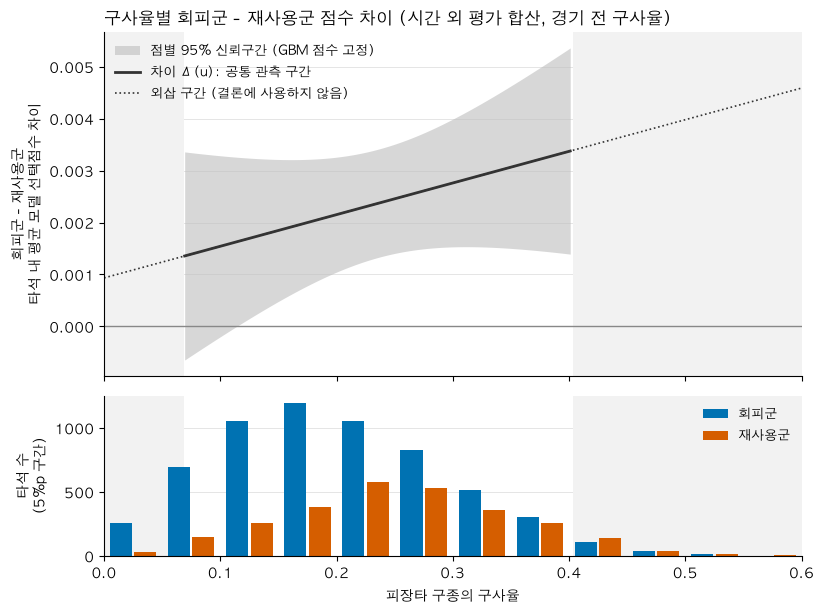

공통 관측 구간: 구사율 0.069 ~ 0.403


avoided,재사용군,회피군
구사율 구간,,
"[0.0, 0.1)",173,951
"[0.1, 0.2)",647,2248
"[0.2, 0.3)",1105,1882
"[0.3, 0.4)",613,818
"[0.4, 1.0)",213,163


,구사율,회피군−재사용군 차이,표준오차,95% CI 하한,95% CI 상한
0,0.10,0.00154,0.00089,-0.00020,0.00328
1,0.15,0.00185,0.00070,0.00048,0.00321
2,0.20,0.00215,0.00056,0.00105,0.00326
3,0.25,0.00246,0.00054,0.00140,0.00351
4,0.30,0.00276,0.00063,0.00153,0.00399
5,0.35,0.00307,0.00080,0.00150,0.00463
6,0.40,0.00337,0.00101,0.00139,0.00535


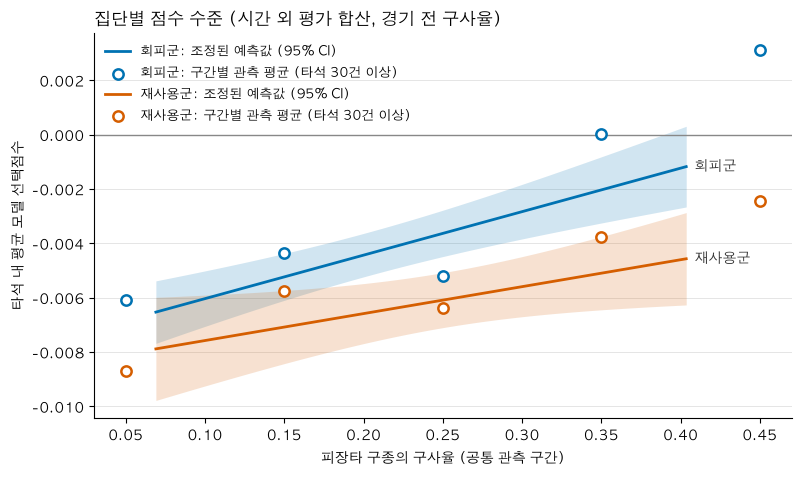

,구사율 구간,집단,타석_수,투수_수,점수_평균,점수_중앙값
0,"[0.0, 0.1)",재사용군,173,112,-0.00868,-0.01084
1,"[0.0, 0.1)",회피군,951,283,-0.00610,-0.00646
2,"[0.1, 0.2)",재사용군,647,249,-0.00576,-0.00526
3,"[0.1, 0.2)",회피군,2248,379,-0.00435,-0.00315
4,"[0.2, 0.3)",재사용군,1105,280,-0.00638,-0.00616
5,"[0.2, 0.3)",회피군,1882,344,-0.00521,-0.00419
6,"[0.3, 0.4)",재사용군,613,172,-0.00375,-0.00350
7,"[0.3, 0.4)",회피군,818,196,0.00002,0.00011
8,"[0.4, 1.0)",재사용군,213,60,-0.00243,-0.00198
9,"[0.4, 1.0)",회피군,163,43,0.00310,0.00294


,결과 변수,avoided 계수,구사율 계수,상호작용 계수,상호작용 SE
0,선택점수 (= 재사용 가정 − 실제),0.00225,0.00991,0.00609,0.00523
1,재사용 가정 예측,0.02360,0.04388,0.00227,0.01366
2,실제 구종 예측,0.02138,0.03270,-0.00254,0.01276


In [13]:
support_oot = plot_delta(fit_oot_pooled, oot_nonfb, 'hit_usage_pregame', USAGE_CENTER_PRE, 'hit_usage_pregame_c',
                         '구사율별 회피군 - 재사용군 점수 차이 (시간 외 평가 합산, 경기 전 구사율)',
                         os.path.join(FIG_DIR, '11_delta_by_usage_out_of_time.png'))
print(f'공통 관측 구간: 구사율 {support_oot[0]:.3f} ~ {support_oot[1]:.3f}')
display(usage_bin_counts(oot_nonfb, 'hit_usage_pregame'))
display(delta_table(fit_oot_pooled, USAGE_CENTER_PRE, 'hit_usage_pregame_c', support_oot).round(5))
bins_oot = plot_group_curves(fit_oot_pooled, oot_nonfb, 'hit_usage_pregame', USAGE_CENTER_PRE, 'hit_usage_pregame_c', support_oot,
                             '집단별 점수 수준 (시간 외 평가 합산, 경기 전 구사율)',
                             os.path.join(FIG_DIR, '11_group_scores_out_of_time.png'))
display(bins_oot.round(5))
decomp_oot = decomposition_table(oot_nonfb, 'hit_usage_pregame_c', COV_START)
display(decomp_oot.round(5))

## 7. 전체 과정 부트스트랩 (새 검증)

4~6절의 신뢰구간은 GBM 점수를 고정했을 때의 것입니다. GBM을 다시 학습하면 점수 자체가 달라지므로,
그 불확실성까지 포함하려면 점수를 만드는 과정 전체를 다시 돌려야 합니다. 이전 버전의 "OLS 부트스트랩
표준편차와 `lmer` 표준오차를 제곱합한 보수적 SE"는 두 불확실성을 임의로 더한 값이라 **더 이상 검정
근거로 쓰지 않습니다.** 대신 아래 절차의 백분위 구간을 씁니다.

1. **투수 단위 재표집**: 투수를 복원추출합니다. 뽑힌 투수의 학습 기록(타석 종료 투구)과 평가 기록
   (재대결)을 함께 가져오고, 두 번 뽑힌 투수는 **서로 다른 투수 ID**를 받습니다.
2. **GBM 재적합**: 시간 분할을 유지한 채(평가 시즌 이전만 학습) 각 평가 시즌의 GBM을 다시 학습합니다.
3. **평가 점수 재계산**: 재적합한 GBM으로 선택점수를 다시 계산합니다.
4. **같은 혼합모형 재적합**: 6절과 같은 `lmer` 공식을 그대로 다시 적합합니다(OLS로 바꾸지 않음).

경기 전 구사율은 각 투수 자신의 기록만으로 계산되므로 투수 재표집과 무관하게 그대로 따라옵니다.
평활 강도 `k`는 6절에서 정한 값으로 고정합니다(재표집마다 다시 고르지 않음 — 이 부분의 불확실성은
포함되지 않습니다).

In [14]:
pitcher_pool = np.array(sorted(set(decisive_pre['pitcher']) | set(oot_nonfb['pitcher'])))
decisive_index = decisive_pre.groupby('pitcher').indices
boot_events = {y: oot_nonfb[oot_nonfb['season'] == y].reset_index(drop=True) for y in OOT_FOLD_SEASONS}
boot_event_index = {y: boot_events[y].groupby('pitcher').indices for y in OOT_FOLD_SEASONS}
boot_pa = {y: pa_pre_by_season[y].merge(boot_events[y][PA_KEYS], on=PA_KEYS) for y in OOT_FOLD_SEASONS}
BOOT_COLUMNS = [*PA_KEYS, 'avoided', 'hit_usage_pregame_c', *COV_START, 'season']
BOOT_USAGE_POINTS = (0.10, 0.30)


def run_full_bootstrap(n_boot: int, seed: int):
    rng = np.random.default_rng(seed)
    records, failures = [], []
    for b in range(n_boot):
        sampled = rng.choice(pitcher_pool, size=len(pitcher_pool), replace=True)
        train_rows, _ = expand_by_pitcher(decisive_index, sampled)
        train_season = SEASON_PRE[train_rows]
        parts = []
        for y in OOT_FOLD_SEASONS:
            rows = train_rows[train_season < y]
            model = HistGradientBoostingRegressor(categorical_features='from_dtype', random_state=seed + b, max_iter=200,
                                                  early_stopping=True).fit(X_PRE.iloc[rows], Y_PRE[rows])
            scored = boot_events[y][BOOT_COLUMNS].merge(
                score_pa(boot_pa[y], model, FEATURES_PREGAME, 'hit_usage_pregame', 'pregame_usage'), on=PA_KEYS)
            event_rows, replicate = expand_by_pitcher(boot_event_index[y], sampled)
            parts.append(scored.iloc[event_rows].assign(pitcher_id=[f'r{r}' for r in replicate]))
        sample = pd.concat(parts, ignore_index=True)
        record = {'replicate': b}
        for name, data, season_fe in (('pooled', sample, True), ('primary', sample[sample['season'] == PRIMARY_EVAL_SEASON], False)):
            try:
                fit = fit_mixed(data, 'selection_score', 'hit_usage_pregame_c', COV_START, season_fe)
                record[f'{name}_interaction'] = fit['coef'].loc['avoided:hit_usage_pregame_c', 'estimate']
                for u in BOOT_USAGE_POINTS:
                    record[f'{name}_delta_{u:.2f}'] = delta_at(fit, [u], USAGE_CENTER_PRE, 'hit_usage_pregame_c')[0][0]
            except Exception as exc:  # 적합 실패는 버리지 않고 기록
                failures.append({'replicate': b, 'model': name, 'error': str(exc)[:120]})
        records.append(record)
    return pd.DataFrame(records), pd.DataFrame(failures, columns=['replicate', 'model', 'error'])


_t0 = time.time()
boot, boot_failures = run_full_bootstrap(N_BOOT, RANDOM_STATE)
boot_minutes = (time.time() - _t0) / 60
print(f'설정 반복 수 {N_BOOT}회, 난수 시드 {RANDOM_STATE}, 소요 {boot_minutes:.1f}분')
for name in ('pooled', 'primary'):
    done = int(boot[f'{name}_interaction'].notna().sum()) if f'{name}_interaction' in boot else 0
    print(f'  {name}: 실제 완료 {done}회, 적합 실패 {N_BOOT - done}회 (실패율 {(N_BOOT - done) / N_BOOT:.1%})')
if len(boot_failures):
    display(boot_failures)

2026-10-06 13:42:41,815 [WARNING] R callback write-console: boundary (singular) fit: see help('isSingular')
  


2026-10-06 13:43:29,267 [WARNING] R callback write-console: boundary (singular) fit: see help('isSingular')
  


2026-10-06 13:45:15,771 [WARNING] R callback write-console: boundary (singular) fit: see help('isSingular')
  


2026-10-06 13:47:22,191 [WARNING] R callback write-console: boundary (singular) fit: see help('isSingular')
  


2026-10-06 13:48:47,778 [WARNING] R callback write-console: boundary (singular) fit: see help('isSingular')
  


...

2026-10-06 14:10:48,137 [WARNING] R callback write-console: boundary (singular) fit: see help('isSingular')
  


2026-10-06 14:11:06,366 [WARNING] R callback write-console: boundary (singular) fit: see help('isSingular')
  


2026-10-06 14:14:56,446 [WARNING] R callback write-console: boundary (singular) fit: see help('isSingular')
  


2026-10-06 14:15:18,690 [WARNING] R callback write-console: boundary (singular) fit: see help('isSingular')
  


설정 반복 수 200회, 난수 시드 20261003, 소요 32.8분
  pooled: 실제 완료 200회, 적합 실패 0회 (실패율 0.0%)
  primary: 실제 완료 200회, 적합 실패 0회 (실패율 0.0%)


In [15]:
def bootstrap_row(label: str, fit: dict, prefix: str) -> list:
    rows = []
    quantities = [('상호작용 계수', fit['coef'].loc['avoided:hit_usage_pregame_c', 'estimate'],
                   fit['coef'].loc['avoided:hit_usage_pregame_c', ['ci_low', 'ci_high']].to_numpy(), f'{prefix}_interaction')]
    for u in BOOT_USAGE_POINTS:
        d, se = delta_at(fit, [u], USAGE_CENTER_PRE, 'hit_usage_pregame_c')
        quantities.append((f'차이 Δ(구사율 {u:.2f})', d[0], np.array([d[0] - 1.96 * se[0], d[0] + 1.96 * se[0]]), f'{prefix}_delta_{u:.2f}'))
    for name, estimate, fixed_ci, col in quantities:
        draws = boot[col].dropna().to_numpy() if col in boot else np.array([])
        row = {'표본': label, '추정 대상': name, '점추정': estimate,
               'GBM 고정 95% CI': f'[{fixed_ci[0]:+.5f}, {fixed_ci[1]:+.5f}]', '부트스트랩 완료 수': len(draws)}
        if len(draws) >= 2:
            lo, hi = np.percentile(draws, [2.5, 97.5])
            row.update({'부트스트랩 SD': draws.std(ddof=1), '전체 과정 95% 백분위 구간': f'[{lo:+.5f}, {hi:+.5f}]',
                        '음수인 반복 비율': float((draws < 0).mean()), '_lo': lo, '_hi': hi})
        rows.append(row)
    return rows


boot_summary = pd.DataFrame(bootstrap_row('시간 외 합산 (2022~2026)', fit_oot_pooled, 'pooled')
                            + bootstrap_row(f'주 분할 ({PRIMARY_EVAL_SEASON} 평가)', fit_oot_primary, 'primary'))
print('GBM 고정 신뢰구간과, GBM 재학습까지 포함한 전체 과정 부트스트랩의 비교:')
display(boot_summary.drop(columns=['_lo', '_hi'], errors='ignore').round(5))

GBM 고정 신뢰구간과, GBM 재학습까지 포함한 전체 과정 부트스트랩의 비교:


,표본,추정 대상,점추정,GBM 고정 95% CI,부트스트랩 완료 수,부트스트랩 SD,전체 과정 95% 백분위 구간,음수인 반복 비율
0,시간 외 합산 (2022~2026),상호작용 계수,0.00609,"[-0.00416, +0.01634]",200,0.01592,"[-0.03519, +0.02807]",0.710
1,시간 외 합산 (2022~2026),차이 Δ(구사율 0.10),0.00154,"[-0.00020, +0.00328]",200,0.00251,"[-0.00149, +0.00813]",0.095
2,시간 외 합산 (2022~2026),차이 Δ(구사율 0.30),0.00276,"[+0.00153, +0.00399]",200,0.00180,"[-0.00130, +0.00542]",0.120
3,주 분할 (2026 평가),상호작용 계수,-0.02828,"[-0.05455, -0.00202]",200,0.02990,"[-0.10607, +0.01128]",0.920
4,주 분할 (2026 평가),차이 Δ(구사율 0.10),0.00605,"[+0.00198, +0.01012]",200,0.00419,"[+0.00201, +0.01704]",0.000
5,주 분할 (2026 평가),차이 Δ(구사율 0.30),0.00039,"[-0.00273, +0.00352]",200,0.00355,"[-0.00686, +0.00690]",0.445


## 8. 제한된 민감도 분석 (새 검증)

유의한 사양을 고르기 위한 탐색이 아니라, 미리 정한 두 가지 변경에서 결과가 어떻게 달라지는지 그대로
보여주는 표입니다. 두 변경은 성격이 다릅니다.

* **GBM에서 구사율 입력 제거 — 점수를 만드는 모델이 달라지는 분석.** 구사율은 회귀의 조절변수이면서
  동시에 GBM의 입력이기도 합니다. 구종을 바꿀 때 구사율 입력도 함께 바뀌므로, 상호작용이 "GBM이 구사율
  입력에 반응한 결과"일 가능성이 있습니다. GBM에서 구사율을 빼도 방향이 유지되는지 봅니다.
* **패스트볼 포함 — 분석 대상이 달라지는 분석.** 같은 모델로, 패스트볼 계열 피장타까지 포함한 재대결
  전체에서 어떤 패턴이 나오는지 봅니다.

각 변경을 기존 모형(전체 시즌 적합)과 시간 외 합산 평가 양쪽에서 계산합니다. 신뢰구간은 GBM 점수 고정
기준입니다(이 표의 사양들에는 전체 과정 부트스트랩을 돌리지 않았습니다).

In [16]:
sens_rows = [
    {'변경': '기준', '평가 방식': '전체 시즌 적합', **summarize_interaction('비패스트볼, 구사율 입력 포함', fit_base, USAGE_CENTER_SEASON, 'hit_usage_season_c')},
    {'변경': '기준', '평가 방식': '시간 외 합산', **summarize_interaction('비패스트볼, 구사율 입력 포함', fit_oot_pooled, USAGE_CENTER_PRE, 'hit_usage_pregame_c')},
]

# (가) GBM에서 구사율 입력 제거 -- 점수를 만드는 모델이 달라짐
gbm_no_usage = fit_gbm(decisive_table, FEATURES_NO_USAGE)
ev_a = events_nonfb.drop(columns=SCORE_COLUMNS).merge(score_pa(pa_pitches, gbm_no_usage, FEATURES_NO_USAGE, None, None), on=PA_KEYS)
fit_a_full = fit_mixed(ev_a, 'selection_score', 'hit_usage_season_c', COV_DECISIVE)
fold_models_no_usage = fit_fold_models(FEATURES_NO_USAGE)
ev_a_oot = oot_nonfb.drop(columns=SCORE_COLUMNS).merge(score_out_of_time(fold_models_no_usage, FEATURES_NO_USAGE, None, None), on=PA_KEYS)
fit_a_oot = fit_mixed(ev_a_oot, 'selection_score', 'hit_usage_pregame_c', COV_START)
sens_rows += [
    {'변경': '(가) 모델 변경', '평가 방식': '전체 시즌 적합', **summarize_interaction('비패스트볼, GBM 구사율 입력 제거', fit_a_full, USAGE_CENTER_SEASON, 'hit_usage_season_c')},
    {'변경': '(가) 모델 변경', '평가 방식': '시간 외 합산', **summarize_interaction('비패스트볼, GBM 구사율 입력 제거', fit_a_oot, USAGE_CENTER_PRE, 'hit_usage_pregame_c')},
]

# (나) 패스트볼 포함 -- 분석 대상이 달라짐 (중심화 기준은 비패스트볼 표본의 평균을 그대로 써서 Δ(u)를 같은 눈금으로 비교)
ev_b = events.assign(hit_usage_season_c=events['hit_usage_season'] - USAGE_CENTER_SEASON)
fit_b_full = fit_mixed(ev_b, 'selection_score', 'hit_usage_season_c', COV_DECISIVE)
fit_b_oot = fit_mixed(events_oot, 'selection_score', 'hit_usage_pregame_c', COV_START)
sens_rows += [
    {'변경': '(나) 대상 변경', '평가 방식': '전체 시즌 적합', **summarize_interaction('패스트볼 포함 전체, 구사율 입력 포함', fit_b_full, USAGE_CENTER_SEASON, 'hit_usage_season_c')},
    {'변경': '(나) 대상 변경', '평가 방식': '시간 외 합산', **summarize_interaction('패스트볼 포함 전체, 구사율 입력 포함', fit_b_oot, USAGE_CENTER_PRE, 'hit_usage_pregame_c')},
]
sensitivity = pd.DataFrame(sens_rows)
display(sensitivity.round(5))

,변경,평가 방식,사양,재대결 건수,투수 수,상호작용 계수,95% CI 하한,95% CI 상한,구사율 10%p당 차이 변화,차이(구사율 0.10),차이(구사율 0.10) 95% CI,차이(구사율 0.30),차이(구사율 0.30) 95% CI
0,기준,전체 시즌 적합,"비패스트볼, 구사율 입력 포함",10747,616,-0.06446,-0.07486,-0.05406,-0.00645,0.01015,"[+0.0084, +0.0119]",-0.00274,"[-0.0040, -0.0015]"
1,기준,시간 외 합산,"비패스트볼, 구사율 입력 포함",8813,535,0.00609,-0.00416,0.01634,0.00061,0.00154,"[-0.0002, +0.0033]",0.00276,"[+0.0015, +0.0040]"
2,(가) 모델 변경,전체 시즌 적합,"비패스트볼, GBM 구사율 입력 제거",10747,616,0.01271,0.00397,0.02145,0.00127,0.00199,"[+0.0005, +0.0034]",0.00453,"[+0.0035, +0.0056]"
3,(가) 모델 변경,시간 외 합산,"비패스트볼, GBM 구사율 입력 제거",8813,535,0.01637,0.00606,0.02667,0.00164,0.00121,"[-0.0005, +0.0030]",0.00448,"[+0.0032, +0.0057]"
4,(나) 대상 변경,전체 시즌 적합,"패스트볼 포함 전체, 구사율 입력 포함",27245,695,-0.04165,-0.04589,-0.03740,-0.00416,0.00887,"[+0.0078, +0.0099]",0.00054,"[-0.0001, +0.0011]"
5,(나) 대상 변경,시간 외 합산,"패스트볼 포함 전체, 구사율 입력 포함",22043,599,0.01493,0.01077,0.01909,0.00149,-0.00074,"[-0.0018, +0.0003]",0.00224,"[+0.0016, +0.0028]"


### 선형 가정 점검 (고정 자유도 스플라인)

구사율과의 관계를 직선으로 둔 것이 무리한 가정인지, 자유도 3의 자연 3차 스플라인으로 바꿔 비교합니다.
자유도는 미리 3으로 고정했고, 가장 유의한 절단점을 찾는 탐색은 하지 않습니다. 대상은 시간 외 합산
표본입니다.

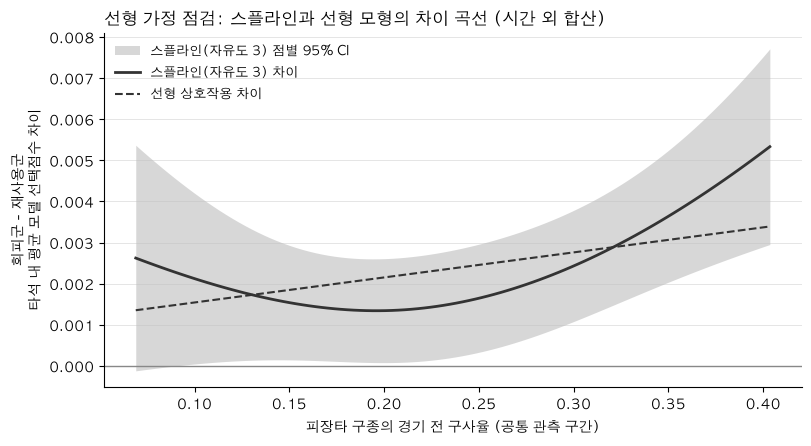

선형 모형 대 스플라인 모형 우도비 검정 p = 0.0036 (작을수록 직선만으로는 부족하다는 뜻)


In [17]:
SPLINE_DF = 3
spline_design = patsy.dmatrix(f'cr(u, df={SPLINE_DF}) - 1', {'u': oot_nonfb['hit_usage_pregame'].to_numpy()})
spline_cols = [f's{i + 1}' for i in range(SPLINE_DF)]
ev_spline = oot_nonfb.assign(**{c: np.asarray(spline_design)[:, i] for i, c in enumerate(spline_cols)})
# cr 기저는 합이 1이라 절편과 겹치므로 마지막 기저를 기준으로 뺀다
spline_terms = spline_cols[:-1]
spline_rhs = f"avoided * ({' + '.join(spline_terms)}) + {' + '.join(COV_START)} + factor(season) + (1 | pitcher_id)"
linear_rhs = f"avoided * hit_usage_pregame_c + {' + '.join(COV_START)} + factor(season) + (1 | pitcher_id)"
fit_lmer(ev_spline[['selection_score', 'avoided', *spline_terms, 'hit_usage_pregame_c', *COV_START, 'season', 'pitcher_id']],
         f'selection_score ~ {spline_rhs}')
spline_coef, spline_vcov = extract_lmer_fixed_effects().set_index('term'), extract_fixed_effects_vcov()
ro.r(f'm_lin <- lmer(selection_score ~ {linear_rhs}, data = model_data, REML = FALSE)')
ro.r(f'm_spl <- lmer(selection_score ~ {spline_rhs}, data = model_data, REML = FALSE)')
lrt_p = float(ro.r('anova(m_lin, m_spl)[2, "Pr(>Chisq)"]')[0])

grid_s = np.linspace(support_oot[0], support_oot[1], 100)
basis_grid = np.asarray(patsy.build_design_matrices([spline_design.design_info], {'u': grid_s})[0])[:, :-1]
contrast_terms = ['avoided', *[f'avoided:{c}' for c in spline_terms]]
contrast = np.column_stack([np.ones(len(grid_s)), basis_grid])
delta_spline = contrast @ spline_coef.loc[contrast_terms, 'estimate'].to_numpy()
se_spline = np.sqrt(np.einsum('ij,jk,ik->i', contrast, spline_vcov.loc[contrast_terms, contrast_terms].to_numpy(), contrast))
delta_linear, se_linear = delta_at(fit_oot_pooled, grid_s, USAGE_CENTER_PRE, 'hit_usage_pregame_c')

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.axhline(0, color='#888888', lw=1)
ax.fill_between(grid_s, delta_spline - 1.96 * se_spline, delta_spline + 1.96 * se_spline, color='#BDBDBD', alpha=0.6, lw=0,
                label=f'스플라인(자유도 {SPLINE_DF}) 점별 95% CI')
ax.plot(grid_s, delta_spline, color=COLOR_INK, lw=2, label=f'스플라인(자유도 {SPLINE_DF}) 차이')
ax.plot(grid_s, delta_linear, color=COLOR_INK, lw=1.5, ls='--', label='선형 상호작용 차이')
ax.set_xlabel('피장타 구종의 경기 전 구사율 (공통 관측 구간)')
ax.set_ylabel(f'회피군 - 재사용군\n{SCORE_LABEL} 차이')
ax.set_title('선형 가정 점검: 스플라인과 선형 모형의 차이 곡선 (시간 외 합산)', loc='left', fontsize=12)
ax.legend(frameon=False, fontsize=9)
ax.grid(axis='y', color='#E5E5E5', lw=0.7)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
fig.savefig(os.path.join(FIG_DIR, '11_spline_check_out_of_time.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'선형 모형 대 스플라인 모형 우도비 검정 p = {lrt_p:.4f} (작을수록 직선만으로는 부족하다는 뜻)')

## 9. 최종 결론

아래 요약은 이 노트북을 실행한 결과값으로 코드가 작성합니다(수치를 본문에 따로 적어 두지 않습니다).
결론의 근거는 **시간 외 합산 평가의 전체 과정 부트스트랩 구간**이고, 주 분할(2026년 평가)과 민감도
분석은 그 결론이 어디까지 유지되는지를 보여주는 보조 근거입니다.

In [18]:
def _fmt(x: float) -> str:
    return f'{x:+.4f}'


def boot_interval(sample_label: str, quantity: str):
    row = boot_summary[(boot_summary['표본'].str.startswith(sample_label)) & (boot_summary['추정 대상'] == quantity)].iloc[0]
    return row


pooled_it = boot_interval('시간 외 합산', '상호작용 계수')
primary_it = boot_interval('주 분할', '상호작용 계수')
has_boot = '_hi' in boot_summary and pd.notna(pooled_it.get('_hi', np.nan))
sens_signs = sensitivity.set_index(['변경', '평가 방식'])['상호작용 계수']
no_usage_keeps_sign = bool((sens_signs.loc['(가) 모델 변경'] < 0).all())
with_fb_keeps_sign = bool((sens_signs.loc['(나) 대상 변경'] < 0).all())

def interval_status(row) -> str:
    if not (has_boot and pd.notna(row.get('_hi', np.nan))):
        return 'unknown'
    return 'negative' if row['_hi'] < 0 else ('positive' if row['_lo'] > 0 else 'includes_zero')


STATUS_TEXT = {'negative': '0보다 작습니다', 'positive': '0보다 큽니다', 'includes_zero': '0을 포함합니다', 'unknown': '계산되지 않았습니다'}
pooled_status, primary_status = interval_status(pooled_it), interval_status(primary_it)
pooled_d10, pooled_d30 = boot_interval('시간 외 합산', '차이 Δ(구사율 0.10)'), boot_interval('시간 외 합산', '차이 Δ(구사율 0.30)')
attr = attribution.set_index(['GBM 학습 범위', '구사율 정의'])['상호작용 계수']

lines = ['### 실행 결과 요약', '']
lines.append(f'* **기존 결과 재현.** 노트북 09의 평균 차이는 {_fmt(fit_09["coef"].loc["avoided", "estimate"])}, '
             f'기존 11번 상호작용 계수는 {_fmt(fit_base["coef"].loc["avoided:hit_usage_season_c", "estimate"])}로 재현됐습니다.')
if has_boot:
    lines.append(f'* **시간 외 합산 평가 (재대결 {fit_oot_pooled["n"]:,}건).** 상호작용 계수 {_fmt(pooled_it["점추정"])}, '
                 f'GBM 고정 95% CI {pooled_it["GBM 고정 95% CI"]}, 전체 과정 부트스트랩 95% 구간 {pooled_it["전체 과정 95% 백분위 구간"]} '
                 f'(완료 {int(pooled_it["부트스트랩 완료 수"])}회 중 음수 {pooled_it["음수인 반복 비율"]:.1%}) — 구간이 {STATUS_TEXT[pooled_status]}.')
    lines.append(f'* **주 분할 ({PRIMARY_EVAL_SEASON}년 평가, 재대결 {fit_oot_primary["n"]:,}건).** 상호작용 계수 {_fmt(primary_it["점추정"])}, '
                 f'전체 과정 부트스트랩 95% 구간 {primary_it["전체 과정 95% 백분위 구간"]} '
                 f'(음수 {primary_it["음수인 반복 비율"]:.1%}) — 구간이 {STATUS_TEXT[primary_status]}.')
    lines.append(f'* **시간 외 합산에서의 집단 간 차이 수준.** 구사율 0.10에서 {_fmt(pooled_d10["점추정"])} (부트스트랩 구간 {pooled_d10["전체 과정 95% 백분위 구간"]}), '
                 f'구사율 0.30에서 {_fmt(pooled_d30["점추정"])} (부트스트랩 구간 {pooled_d30["전체 과정 95% 백분위 구간"]}).')
else:
    lines.append('* **전체 과정 부트스트랩이 완료되지 않아** 아래 판단은 GBM 점수 고정 신뢰구간에만 근거합니다.')
usage_shift = float((attr.xs('경기 전', level='구사율 정의') - attr.xs('시즌 전체', level='구사율 정의')).mean())
scope_shift = float((attr.xs('평가 시즌 이전만', level='GBM 학습 범위') - attr.xs('전체 시즌 (평가 시즌 포함)', level='GBM 학습 범위')).mean())
lines.append('* **어느 변경이 결과를 바꿨는가 (같은 표본·같은 공변량).** 상호작용 계수는 '
             + '; '.join(f'{scope} + {usage} 구사율 {_fmt(v)}' for (scope, usage), v in attr.items()) + '입니다. '
             f'구사율 정의를 시즌 전체에서 경기 전으로 바꾸면 평균 {_fmt(usage_shift)}, GBM 학습 범위를 평가 시즌 이전으로 좁히면 평균 {_fmt(scope_shift)} 달라졌습니다.')
lines.append(f'* **민감도.** GBM에서 구사율 입력을 제거했을 때 상호작용 계수는 전체 시즌 적합 {_fmt(sens_signs.loc[("(가) 모델 변경", "전체 시즌 적합")])}, '
             f'시간 외 합산 {_fmt(sens_signs.loc[("(가) 모델 변경", "시간 외 합산")])}입니다. '
             f'패스트볼을 포함하면 전체 시즌 적합 {_fmt(sens_signs.loc[("(나) 대상 변경", "전체 시즌 적합")])}, '
             f'시간 외 합산 {_fmt(sens_signs.loc[("(나) 대상 변경", "시간 외 합산")])}입니다.')
lines.append(f'* **선형 가정.** 스플라인 대비 우도비 검정 p = {lrt_p:.4f}.')
lines += ['', '### 결론', '']
if pooled_status == 'negative' and no_usage_keeps_sign:
    lines.append('비패스트볼 피장타 후 재대결에서, 회피군의 모델상 상대적 선택점수는 해당 구종의 평소 구사율이 높을수록 낮아졌습니다. '
                 '이 음의 상호작용은 GBM을 평가 시즌 이전 자료로만 학습하고, 구사율을 경기 전 기록만으로 계산하고, '
                 'GBM 재학습의 불확실성까지 투수 단위 부트스트랩으로 반영한 뒤에도 유지됐습니다. '
                 '이는 회피의 합리성을 평가할 때 그 구종에 대한 의존도를 함께 고려해야 함을 시사합니다.')
    if primary_status != 'negative':
        lines.append('')
        lines.append(f'다만 {PRIMARY_EVAL_SEASON}년 한 시즌만 평가한 주 분할에서는 부트스트랩 구간이 {STATUS_TEXT[primary_status]}. '
                     '한 시즌 표본으로는 독립적으로 확인하지 못했으므로, 결론은 여러 시즌을 합친 시간 외 평가에 한정합니다.')
elif pooled_status == 'negative':
    lines.append('시간 외 합산 평가에서는 음의 상호작용이 전체 과정 부트스트랩 구간으로도 유지됐지만, GBM에서 구사율 입력을 제거하면 '
                 '방향이 유지되지 않았습니다. 이 패턴은 GBM이 구사율 입력에 반응한 결과일 가능성을 배제할 수 없으므로, '
                 '"구사율이 높을수록 회피군의 상대 점수가 낮다"는 결론은 현재 점수 정의에 한정된 것으로 읽어야 합니다.')
else:
    lines.append('**기존 11번의 음의 상호작용은 보강 검증에서 유지되지 않았습니다.** '
                 f'GBM을 평가 시즌 이전 자료로만 학습하고 구사율을 경기 전 기록만으로 계산하면, 시간 외 합산 평가의 상호작용 계수는 '
                 f'{_fmt(pooled_it["점추정"])}이고 전체 과정 부트스트랩 구간이 {STATUS_TEXT[pooled_status]}. '
                 '따라서 "피장타 구종의 평소 구사율이 높을수록 회피군의 상대적 선택점수가 낮아진다"는 진술은 이 자료로 지지되지 않습니다.')
    lines.append('')
    if not no_usage_keeps_sign:
        main_driver = ('구사율 정의(시즌 전체 집계 → 경기 전 기록)' if abs(usage_shift) > abs(scope_shift)
                       else 'GBM 학습 범위(평가 시즌 포함 → 이전 시즌만)')
        lines.append(f'기존 결과가 어디서 나왔는지도 확인됐습니다. 같은 표본에서 두 요인을 하나씩 바꾼 표(6절)에서 추정치를 크게 움직인 것은 {main_driver}였고, '
                     'GBM에서 구사율 입력만 빼도 상호작용의 부호가 바뀝니다(8절). '
                     '시즌 전체 구사율에는 그 재대결 이후의 투구, 곧 장타를 맞은 뒤 그 구종을 덜 또는 더 던진 결과가 함께 들어 있어서, '
                     '조절변수와 GBM 입력이 회피 여부 자체와 얽혀 있었습니다. 기존의 음의 상호작용은 재대결에서의 선택 패턴이라기보다 '
                     '이 얽힘에 크게 의존한 결과로 보는 것이 타당합니다.')
        lines.append('')
    if interval_status(pooled_d10) == 'positive' and interval_status(pooled_d30) == 'positive':
        lines.append('한편 시간 외 합산 평가에서 회피군의 점수가 재사용군보다 조금 높다는 차이 자체는 구사율 0.10과 0.30 두 지점 모두에서 '
                     '부트스트랩 구간이 0보다 컸습니다. 즉 노트북 09가 본 "작은 양의 평균 차이"와 같은 방향의 차이는 비패스트볼 표본의 '
                     '시간 외 평가에서도 보이지만, 그 차이가 구사율에 따라 달라진다는 근거는 확인되지 않았습니다.')
    else:
        lines.append('시간 외 합산 평가에서 집단 간 점수 차이의 수준도 구사율 0.10과 0.30 두 지점 모두에서 0과 구별된다고 말하기 어렵습니다'
                     '(부트스트랩 구간은 위 요약 참조). 차이의 방향과 구사율에 따른 변화 모두 이번 검증으로는 확정할 수 없습니다.')
    if primary_status == 'negative':
        lines.append('')
        lines.append(f'{PRIMARY_EVAL_SEASON}년 한 시즌만 평가한 주 분할에서는 부트스트랩 구간이 0보다 작게 나왔지만, 같은 원칙으로 평가한 다섯 시즌을 합치면 '
                     '그 방향이 유지되지 않습니다. 한 시즌에서만 보이는 결과이므로 음의 상호작용의 근거로 삼지 않습니다.')
    lines.append('')
    lines.append('연구 흐름으로 정리하면, "09의 전체 평균 차이는 작다 → 그 차이가 구종 의존도에 따라 달라지는가"라는 질문에 대한 '
                 '현재의 답은 "기존 모형에서는 그렇게 보였지만, 시간 순서를 지키고 GBM 재학습의 불확실성을 반영하면 확인되지 않는다"입니다.')
lines += ['', '### 이 결과로 말할 수 없는 것', '',
          '* 점수는 GBM의 예측 차이이지 실제 타석 결과가 아닙니다. "회피해서 실제 성적이 나빠졌다/좋아졌다"는 이 분석의 결론이 아닙니다.',
          '* 회피군과 재사용군은 무작위로 나뉜 집단이 아니므로, 차이는 인과효과가 아니라 두 집단의 조정된 점수 차이입니다. '
          '"주무기 회피는 비합리적"이라거나 "심리적 과잉 반응"이라는 해석은 이 자료로 입증되지 않습니다.',
          '* 차이 곡선이 0을 지나는 구사율은 임계값이 아니며, 공통 관측 구간 밖의 구사율에 대해서는 말할 수 없습니다.',
          '* 평가 시즌들은 이전 탐색에 이미 쓰인 자료이므로, 시간 외 평가는 새 GBM의 학습에서 제외됐다는 뜻일 뿐 한 번도 보지 않은 확증 표본이 아닙니다.',
          '', '### 실행 범위', '',
          f'* 실행한 검증: 기존 결과 재현, 구사율별 차이·집단별 점수(기존 모형과 시간 외 합산), 시간 외 평가 2종, '
          f'변경 요인 분리 표, 전체 과정 부트스트랩 {N_BOOT}회 설정(완료 수는 7절 표), 민감도 2종, 스플라인 선형성 점검.',
          '* 실행하지 않은 것: 민감도 사양들에 대한 전체 과정 부트스트랩, 평활 강도 k 선택의 불확실성 반영, 타깃 변경(xwOBA·카운트 기반) 검증.']
display(Markdown('\n'.join(lines)))

### 실행 결과 요약

* **기존 결과 재현.** 노트북 09의 평균 차이는 +0.0023, 기존 11번 상호작용 계수는 -0.0645로 재현됐습니다.
* **시간 외 합산 평가 (재대결 8,813건).** 상호작용 계수 +0.0061, GBM 고정 95% CI [-0.00416, +0.01634], 전체 과정 부트스트랩 95% 구간 [-0.03519, +0.02807] (완료 200회 중 음수 71.0%) — 구간이 0을 포함합니다.
* **주 분할 (2026년 평가, 재대결 1,096건).** 상호작용 계수 -0.0283, 전체 과정 부트스트랩 95% 구간 [-0.10607, +0.01128] (음수 92.0%) — 구간이 0을 포함합니다.
* **시간 외 합산에서의 집단 간 차이 수준.** 구사율 0.10에서 +0.0015 (부트스트랩 구간 [-0.00149, +0.00813]), 구사율 0.30에서 +0.0028 (부트스트랩 구간 [-0.00130, +0.00542]).
* **어느 변경이 결과를 바꿨는가 (같은 표본·같은 공변량).** 상호작용 계수는 전체 시즌 (평가 시즌 포함) + 시즌 전체 구사율 -0.0670; 전체 시즌 (평가 시즌 포함) + 경기 전 구사율 +0.0059; 평가 시즌 이전만 + 시즌 전체 구사율 -0.0599; 평가 시즌 이전만 + 경기 전 구사율 +0.0061입니다. 구사율 정의를 시즌 전체에서 경기 전으로 바꾸면 평균 +0.0694, GBM 학습 범위를 평가 시즌 이전으로 좁히면 평균 +0.0036 달라졌습니다.
* **민감도.** GBM에서 구사율 입력을 제거했을 때 상호작용 계수는 전체 시즌 적합 +0.0127, 시간 외 합산 +0.0164입니다. 패스트볼을 포함하면 전체 시즌 적합 -0.0416, 시간 외 합산 +0.0149입니다.
* **선형 가정.** 스플라인 대비 우도비 검정 p = 0.0036.

### 결론

**기존 11번의 음의 상호작용은 보강 검증에서 유지되지 않았습니다.** GBM을 평가 시즌 이전 자료로만 학습하고 구사율을 경기 전 기록만으로 계산하면, 시간 외 합산 평가의 상호작용 계수는 +0.0061이고 전체 과정 부트스트랩 구간이 0을 포함합니다. 따라서 "피장타 구종의 평소 구사율이 높을수록 회피군의 상대적 선택점수가 낮아진다"는 진술은 이 자료로 지지되지 않습니다.

기존 결과가 어디서 나왔는지도 확인됐습니다. 같은 표본에서 두 요인을 하나씩 바꾼 표(6절)에서 추정치를 크게 움직인 것은 구사율 정의(시즌 전체 집계 → 경기 전 기록)였고, GBM에서 구사율 입력만 빼도 상호작용의 부호가 바뀝니다(8절). 시즌 전체 구사율에는 그 재대결 이후의 투구, 곧 장타를 맞은 뒤 그 구종을 덜 또는 더 던진 결과가 함께 들어 있어서, 조절변수와 GBM 입력이 회피 여부 자체와 얽혀 있었습니다. 기존의 음의 상호작용은 재대결에서의 선택 패턴이라기보다 이 얽힘에 크게 의존한 결과로 보는 것이 타당합니다.

시간 외 합산 평가에서 집단 간 점수 차이의 수준도 구사율 0.10과 0.30 두 지점 모두에서 0과 구별된다고 말하기 어렵습니다(부트스트랩 구간은 위 요약 참조). 차이의 방향과 구사율에 따른 변화 모두 이번 검증으로는 확정할 수 없습니다.

연구 흐름으로 정리하면, "09의 전체 평균 차이는 작다 → 그 차이가 구종 의존도에 따라 달라지는가"라는 질문에 대한 현재의 답은 "기존 모형에서는 그렇게 보였지만, 시간 순서를 지키고 GBM 재학습의 불확실성을 반영하면 확인되지 않는다"입니다.

### 이 결과로 말할 수 없는 것

* 점수는 GBM의 예측 차이이지 실제 타석 결과가 아닙니다. "회피해서 실제 성적이 나빠졌다/좋아졌다"는 이 분석의 결론이 아닙니다.
* 회피군과 재사용군은 무작위로 나뉜 집단이 아니므로, 차이는 인과효과가 아니라 두 집단의 조정된 점수 차이입니다. "주무기 회피는 비합리적"이라거나 "심리적 과잉 반응"이라는 해석은 이 자료로 입증되지 않습니다.
* 차이 곡선이 0을 지나는 구사율은 임계값이 아니며, 공통 관측 구간 밖의 구사율에 대해서는 말할 수 없습니다.
* 평가 시즌들은 이전 탐색에 이미 쓰인 자료이므로, 시간 외 평가는 새 GBM의 학습에서 제외됐다는 뜻일 뿐 한 번도 보지 않은 확증 표본이 아닙니다.

### 실행 범위

* 실행한 검증: 기존 결과 재현, 구사율별 차이·집단별 점수(기존 모형과 시간 외 합산), 시간 외 평가 2종, 변경 요인 분리 표, 전체 과정 부트스트랩 200회 설정(완료 수는 7절 표), 민감도 2종, 스플라인 선형성 점검.
* 실행하지 않은 것: 민감도 사양들에 대한 전체 과정 부트스트랩, 평활 강도 k 선택의 불확실성 반영, 타깃 변경(xwOBA·카운트 기반) 검증.